Project Description
- You work for the OilyGiant mining company. Your task is to find the best place for a new well.
- Build a model that will help predicting the volume of reserves in the new wells
- Pick the oil wells with the highest estimated values;
- Pick the region with the highest total profit for the selected oil wells.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from math import sqrt
import matplotlib.pyplot as plt
import seaborn as sns

# Read datasets directly from URLs
data_0 = pd.read_csv('https://practicum-content.s3.us-west-1.amazonaws.com/datasets/geo_data_0.csv')
data_1 = pd.read_csv('https://practicum-content.s3.us-west-1.amazonaws.com/datasets/geo_data_1.csv')
data_2 = pd.read_csv('https://practicum-content.s3.us-west-1.amazonaws.com/datasets/geo_data_2.csv')


In [2]:
print("Dataset shape:", data_0.shape)
print("\nColumn names and types:")
display(data_0.dtypes)
print("\nFirst few rows:")
display(data_0.head())



Dataset shape: (100000, 5)

Column names and types:


id          object
f0         float64
f1         float64
f2         float64
product    float64
dtype: object


First few rows:


,id,f0,f1,f2,product
0,txEyH,0.705745,-0.497823,1.221170,105.280062
1,2acmU,1.334711,-0.340164,4.365080,73.037750
2,409Wp,1.022732,0.151990,1.419926,85.265647
3,iJLyR,-0.032172,0.139033,2.978566,168.620776
4,Xdl7t,1.988431,0.155413,4.751769,154.036647


In [3]:
print("Dataset shape:", data_1.shape)
print("\nColumn names and types:")
display(data_1.dtypes)
print("\nFirst few rows:")
display(data_1.head())


Dataset shape: (100000, 5)

Column names and types:


id          object
f0         float64
f1         float64
f2         float64
product    float64
dtype: object


First few rows:


,id,f0,f1,f2,product
0,kBEdx,-15.001348,-8.276000,-0.005876,3.179103
1,62mP7,14.272088,-3.475083,0.999183,26.953261
2,vyE1P,6.263187,-5.948386,5.001160,134.766305
3,KcrkZ,-13.081196,-11.506057,4.999415,137.945408
4,AHL4O,12.702195,-8.147433,5.004363,134.766305


In [4]:
print("Dataset shape:", data_2.shape)
print("\nColumn names and types:")
display(data_2.dtypes)
print("\nFirst few rows:")
display(data_2.head())


Dataset shape: (100000, 5)

Column names and types:


id          object
f0         float64
f1         float64
f2         float64
product    float64
dtype: object


First few rows:


,id,f0,f1,f2,product
0,fwXo0,-1.146987,0.963328,-0.828965,27.758673
1,WJtFt,0.262778,0.269839,-2.530187,56.069697
2,ovLUW,0.194587,0.289035,-5.586433,62.871910
3,q6cA6,2.236060,-0.553760,0.930038,114.572842
4,WPMUX,-0.515993,1.716266,5.899011,149.600746


In [5]:
# Check for duplicates in each dataset
print("DUPLICATE CHECK")
print(f"Data 0 duplicates: {data_0.duplicated().sum()}")
print(f"Data 1 duplicates: {data_1.duplicated().sum()}")
print(f"Data 2 duplicates: {data_2.duplicated().sum()}")

DUPLICATE CHECK
Data 0 duplicates: 0
Data 1 duplicates: 0
Data 2 duplicates: 0


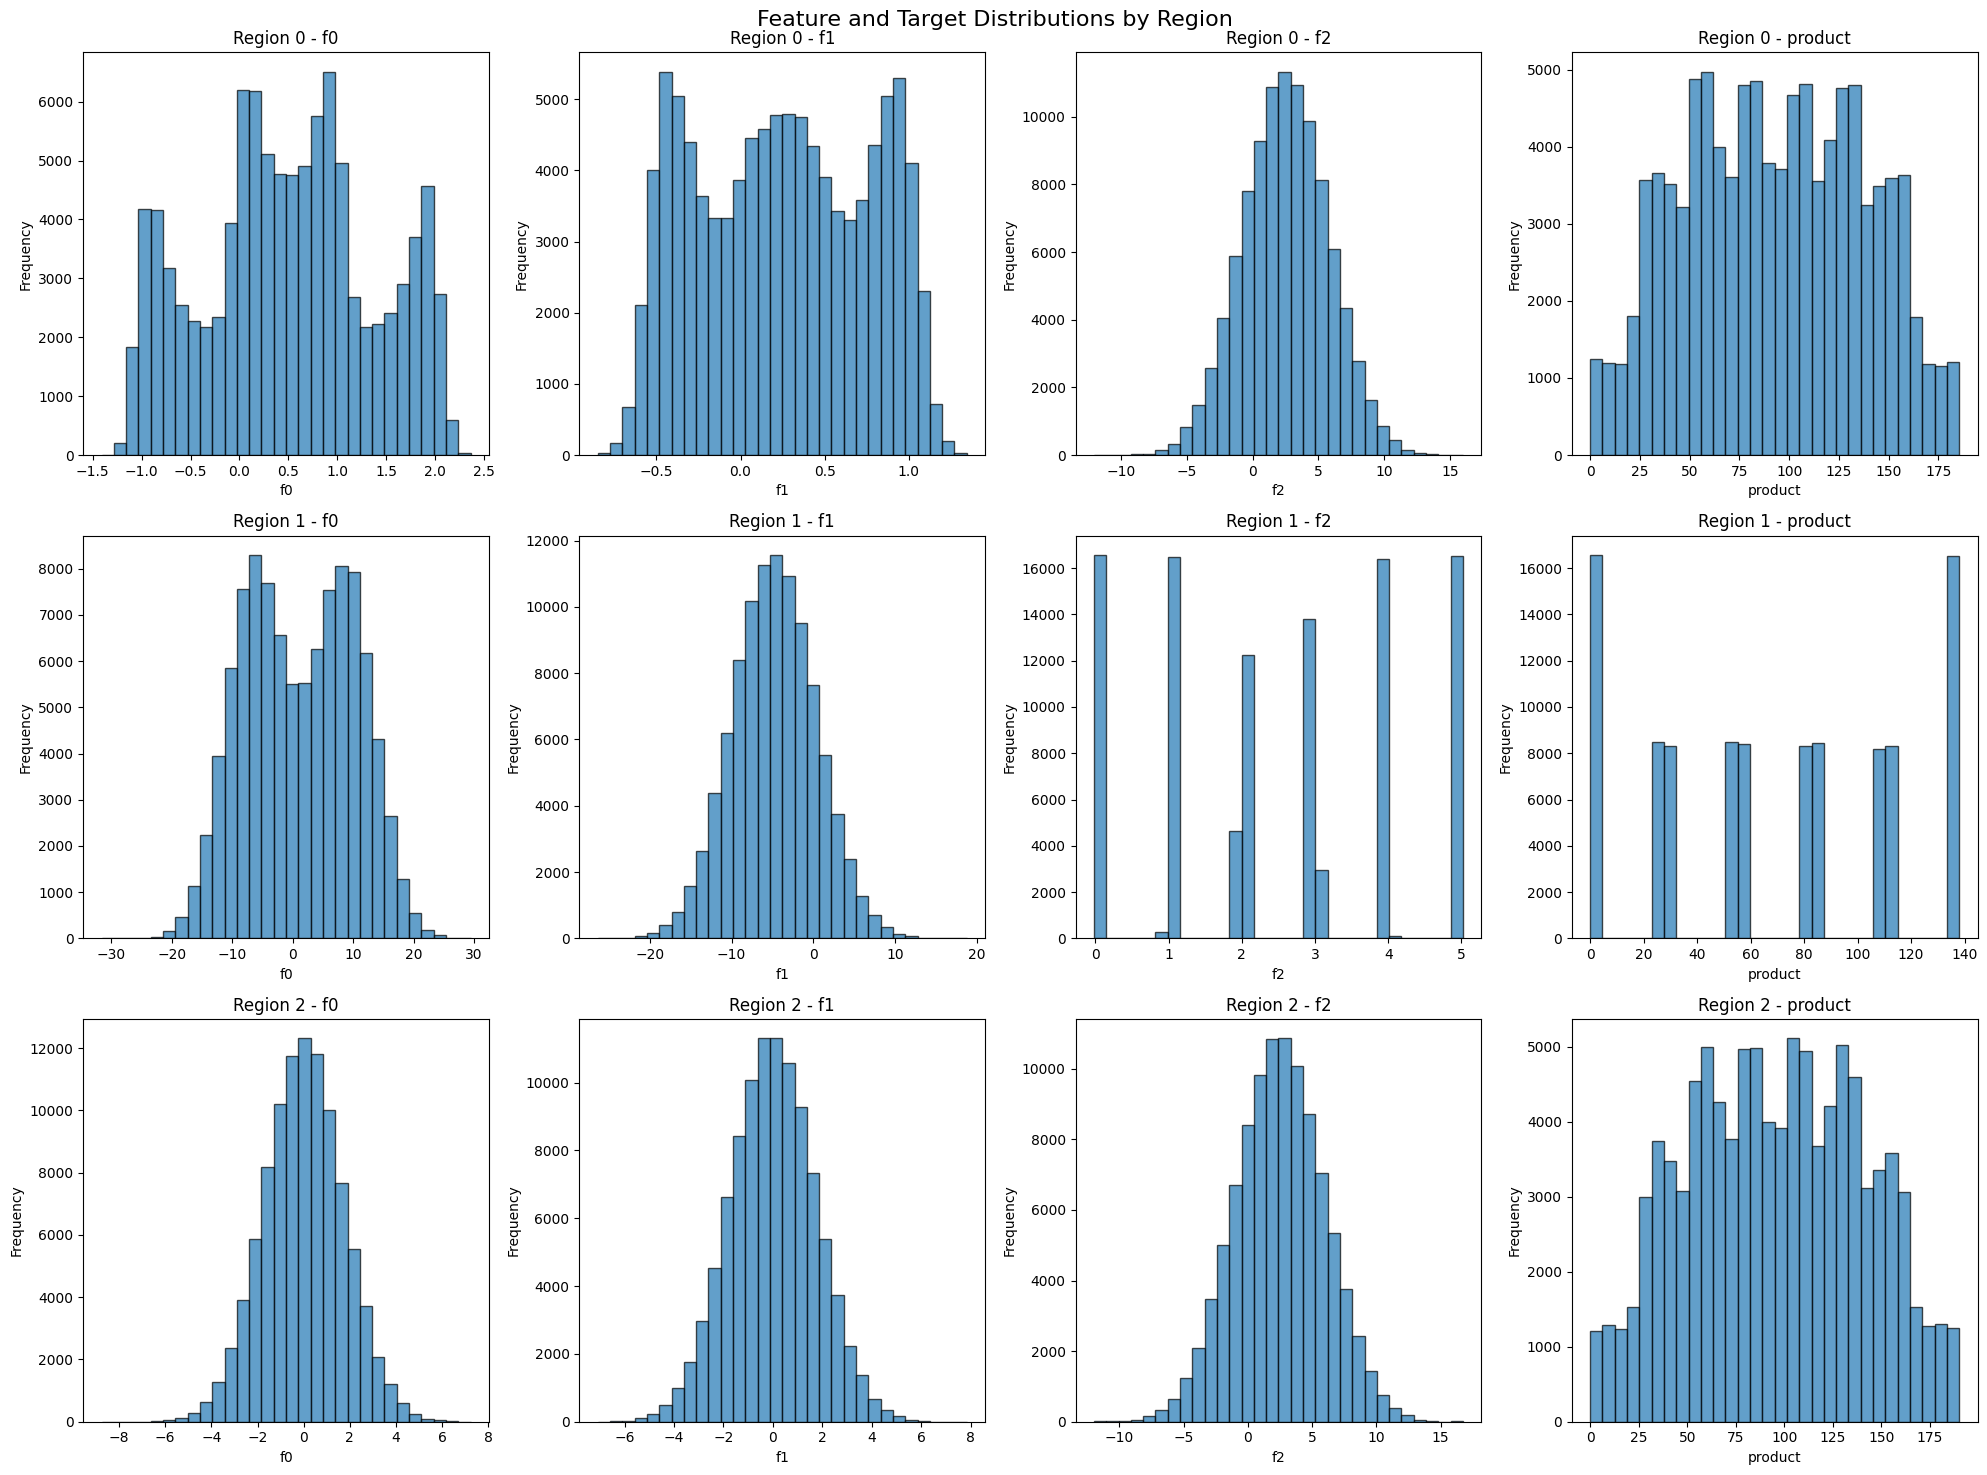

In [6]:
#Chart
plt.style.use('default')
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
fig.suptitle('Feature and Target Distributions by Region', fontsize=16)

datasets = [data_0, data_1, data_2]
region_names = ['Region 0', 'Region 1', 'Region 2']

for i, (data, region_name) in enumerate(zip(datasets, region_names)):
    # Plot f0, f1, f2, and product distributions
    for j, col in enumerate(['f0', 'f1', 'f2', 'product']):
        axes[i, j].hist(data[col], bins=30, alpha=0.7, edgecolor='black')
        axes[i, j].set_title(f'{region_name} - {col}')
        axes[i, j].set_xlabel(col)
        axes[i, j].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [7]:
# Statistical summary for each region
print("STATISTICAL SUMMARY")
for i, (data, region_name) in enumerate(zip(datasets, region_names)):
    print(f"\n{region_name} Statistics:")
    display(data.describe())

STATISTICAL SUMMARY

Region 0 Statistics:


,f0,f1,f2,product
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.500419,0.250143,2.502647,92.500000
std,0.871832,0.504433,3.248248,44.288691
min,-1.408605,-0.848218,-12.088328,0.000000
25%,-0.072580,-0.200881,0.287748,56.497507
50%,0.502360,0.250252,2.515969,91.849972
75%,1.073581,0.700646,4.715088,128.564089
max,2.362331,1.343769,16.003790,185.364347



Region 1 Statistics:


,f0,f1,f2,product
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.141296,-4.796579,2.494541,68.825000
std,8.965932,5.119872,1.703572,45.944423
min,-31.609576,-26.358598,-0.018144,0.000000
25%,-6.298551,-8.267985,1.000021,26.953261
50%,1.153055,-4.813172,2.011479,57.085625
75%,8.621015,-1.332816,3.999904,107.813044
max,29.421755,18.734063,5.019721,137.945408



Region 2 Statistics:


,f0,f1,f2,product
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.002023,-0.002081,2.495128,95.000000
std,1.732045,1.730417,3.473445,44.749921
min,-8.760004,-7.084020,-11.970335,0.000000
25%,-1.162288,-1.174820,0.130359,59.450441
50%,0.009424,-0.009482,2.484236,94.925613
75%,1.158535,1.163678,4.858794,130.595027
max,7.238262,7.844801,16.739402,190.029838


Analysis from charts

Region 0 appears to be the most consistent with 2nd highest max and the lowest deviation. 

In [8]:
#data 0 split

features = data_0[['f0', 'f1', 'f2']] 
target = data_0['product']

X_train_0, X_val_0, y_train_0, y_val_0 = train_test_split(
    features, target,
    test_size=0.25,
    random_state=42
)


In [9]:
#data 1 split

features = data_1[['f0', 'f1', 'f2']] 
target = data_1['product']

X_train_1, X_val_1, y_train_1, y_val_1 = train_test_split(
    features, target,
    test_size=0.25,
    random_state=42
)

In [10]:
#data 2 split

features = data_2[['f0', 'f1', 'f2']] 
target = data_2['product']

X_train_2, X_val_2, y_train_2, y_val_2 = train_test_split(
    features, target,
    test_size=0.25,
    random_state=42
)


In [11]:
data_0_model = LinearRegression()

data_0_model.fit(X_train_0, y_train_0)

data_0_predict = data_0_model.predict(X_val_0)

print(f"Model predictions for Data 0: {data_0_predict}")

mean_prediction_np = np.mean(data_0_predict)
print(f"Mean prediction for Data 0: {mean_prediction_np}")



Model predictions for Data 0: [101.90101715  78.21777385 115.26690103 ...  82.54439653  81.82668931
  93.12106221]
Mean prediction for Data 0: 92.39879990657768


In [12]:
# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_val_0, data_0_predict)

# Calculate RMSE by taking the square root of MSE
rmse = sqrt(mse)

print(f"RMSE Data 0: {rmse}")


RMSE Data 0: 37.75660035026169


In [13]:
data_1_model = LinearRegression()

data_1_model.fit(X_train_1, y_train_1)

data_1_predict = data_1_model.predict(X_val_1)

print(f"Model predictions for Data 1: {data_1_predict}")

mean_prediction_np = np.mean(data_1_predict)
print(f"Mean prediction for Data 1: {mean_prediction_np}")


Model predictions for Data 1: [  0.84473806  52.92161194 135.11038454 ...  26.70873415 109.82308735
 135.44878039]
Mean prediction for Data 1: 68.71287803913762


In [14]:
# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_val_1, data_1_predict)

# Calculate RMSE by taking the square root of MSE
rmse = sqrt(mse)

print(f"RMSE Data 1: {rmse}")



RMSE Data 1: 0.890280100102884


In [15]:
data_2_model = LinearRegression()

data_2_model.fit(X_train_2, y_train_2)

data_2_predict = data_2_model.predict(X_val_2)

print(f"Model predictions for Data 2: {data_2_predict}")

mean_prediction_np = np.mean(data_2_predict)
print(f"Mean prediction for Data 2: {mean_prediction_np}")


Model predictions for Data 2: [ 98.30191642 101.59246124  52.4490989  ...  64.09839     83.76413542
  86.55864415]
Mean prediction for Data 2: 94.77102387765939


In [16]:
# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_val_2, data_2_predict)

# Calculate RMSE by taking the square root of MSE
rmse = sqrt(mse)

print(f"RMSE Data 2: {rmse}")


RMSE Data 2: 40.145872311342174


- Conclusion
- Region 0 Model:
- Mean prediction: 92.40 thousand barrels  
- RMSE: 37.76 = moderate accuracy
  

- Region 1 Model:
- Mean prediction: 68.71 thousand barrels
- RMSE: 0.89 = Most accurate model = safest investment

- Region 2 Model:
- Mean prediction: 94.77 thousand barrels
- RMSE: 40.15 = least accurate model

In [17]:
#store business constants

budget = 100
wells_study = 500
wells_select = 200
revenue_per_unit = 4500


In [18]:
#Cost per well = Total budget ÷ Number of wells

cost_per_well = budget * 1000000 / wells_select  #because budget represents 100 mill dollars
print(f"Cost per well: ${cost_per_well:,.0f}")

Cost per well: $500,000


finding the minimum volume of reserves needed to break even
- Cost per well: \ $500,000
- Revenue per unit: \ $4,500 (from your business constants)
- Break-even condition: Revenue ≥ Cost

In [19]:
min_volume = cost_per_well / revenue_per_unit
print(f"Minimum volume needed per well: {min_volume:.2f} thousand barrels")


Minimum volume needed per well: 111.11 thousand barrels


In [20]:
# Calculate actual average volumes from target data
avg_volume_region_0 = y_val_0.mean()
avg_volume_region_1 = y_val_1.mean()  
avg_volume_region_2 = y_val_2.mean()

print("Break-even vs Actual Average Volume Comparison:")
print(f"Break-even volume needed: {min_volume:.2f} thousand barrels")
print(f"Region 0 actual average: {avg_volume_region_0:.2f} thousand barrels")
print(f"Region 1 actual average: {avg_volume_region_1:.2f} thousand barrels") 
print(f"Region 2 actual average: {avg_volume_region_2:.2f} thousand barrels")

Break-even vs Actual Average Volume Comparison:
Break-even volume needed: 111.11 thousand barrels
Region 0 actual average: 92.33 thousand barrels
Region 1 actual average: 68.73 thousand barrels
Region 2 actual average: 95.15 thousand barrels


- Conclusion
- The average well in each region would actually lose money
- The profitability depends entirely on selecting the top-performing wells

In [21]:
# Sort Region 0 predictions in descending order (highest first)
sorted_predictions_0 = np.sort(data_0_predict)[::-1]

# Select the top 200 wells from Region 0
top_200_region_0 = sorted_predictions_0[:200]

print(f"Highest prediction for Region 0: {top_200_region_0[0]}")
print(f"Lowest prediction for Region 0: {top_200_region_0[199]}")


Highest prediction for Region 0: 176.53610380574955
Lowest prediction for Region 0: 146.87494704892308


In [22]:
# Sort Region 1 predictions in descending order (highest first)
sorted_predictions_1 = np.sort(data_1_predict)[::-1]

# Select the top 200 wells from Region 0
top_200_region_1 = sorted_predictions_1[:200]

print(f"Highest prediction for Region 1: {top_200_region_1[0]}")
print(f"Lowest prediction for Region 1: {top_200_region_1[199]}")


Highest prediction for Region 1: 139.9832769362447
Lowest prediction for Region 1: 138.42380914016985


In [23]:
# Sort Region 2 predictions in descending order (highest first)
sorted_predictions_2 = np.sort(data_2_predict)[::-1]

# Select the top 200 wells from Region 2
top_200_region_2 = sorted_predictions_2[:200]

print(f"Highest prediction for Region 2: {top_200_region_2[0]}")
print(f"Lowest prediction for Region 2: {top_200_region_2[199]}")


Highest prediction for Region 2: 170.52920938757234
Lowest prediction for Region 2: 142.302491996276


In [24]:
total_0 = np.sum(top_200_region_0)
print(f"Total Sum for Region 0: {total_0}")

Total Sum for Region 0: 30881.463288146988


In [25]:
total_1 = np.sum(top_200_region_1)
print(f"Total Sum for Region 1: {total_1}")

Total Sum for Region 1: 27748.75136666462


In [26]:
total_2 = np.sum(top_200_region_2)
print(f"Total Sum for Region 2: {total_2}")

Total Sum for Region 2: 29728.84780825545


In [27]:
profit_0 = (total_0 * 4500) - (wells_select*500000)
print(f"Profit for Region 0: {profit_0}")

Profit for Region 0: 38966584.79666144


In [28]:
profit_1 = (total_1 * 4500) - (wells_select*500000)
print(f"Profit for Region 1: {profit_1}")

Profit for Region 1: 24869381.149990782


In [29]:
profit_2 = (total_2 * 4500) - (wells_select*500000)
print(f"Profit for Region 2: {profit_2}")


Profit for Region 2: 33779815.13714953


Region 0 seems like the best region to develop

- Highest profit potential
- Nearly \$39 million compared to Region 1 (\$24.87M) and Region 2 (\$33.78M)

- Strong reserve predictions
- The top 200 wells show consistently high volumes

- Good model performance
- RMSE of 37.76, which is reasonable for this type of prediction

In [30]:
def calculate_profit(predictions, target_values, wells_to_select=200):
    """Calculate profit from predictions by selecting top wells"""
    # Sort predictions in descending order and select top wells
    top_predictions = np.argsort(predictions)[::-1][:wells_to_select]
    
    # Calculate total reserves and profit
    total_reserves = np.sum(target_values[top_predictions]) # use target values
    revenue = total_reserves * 4500
    cost = wells_to_select * 500000
    profit = revenue - cost
    return profit

In [31]:

def bootstrap_profit_analysis(data_0_predict, y_val_0, calculate_profit, num_samples=500, random_state=None):
    bootstrap_statistics = []
    # RandomState object for reproducibility
    if random_state is not None:
        rng = np.random.RandomState(random_state)
    else:
        rng = np.random
    
    for _ in range(num_samples):
        bootstrap_indices = rng.choice(len(data_0_predict), 500, replace=True)
        bootstrap_predictions = data_0_predict[bootstrap_indices]
        bootstrap_targets = y_val_0.values[bootstrap_indices]
        
        statistic = calculate_profit(bootstrap_predictions, bootstrap_targets)
        bootstrap_statistics.append(statistic)
    
    return bootstrap_statistics

In [32]:
bootstrap_results_0 = bootstrap_profit_analysis(data_0_predict, y_val_0, calculate_profit,random_state=42)

In [33]:
average_profit_0 = np.mean(bootstrap_results_0)
print(f"Region 0 Results:")
print(f"Average Bootstrap Profit: ${average_profit_0:,.0f}")

Region 0 Results:
Average Bootstrap Profit: $4,027,065


In [34]:
confidence_interval_0 = np.percentile(bootstrap_results_0, [2.5, 97.5])
print(f"95% Confidence Interval: ${confidence_interval_0[0]:,.0f} to ${confidence_interval_0[1]:,.0f}")

95% Confidence Interval: $-962,479 to $8,898,625


In [35]:
# Count how many bootstrap samples resulted in losses (profit < 0)
losses = np.sum(np.array(bootstrap_results_0) < 0)
probability_of_loss_0 = losses / len(bootstrap_results_0)
print(f"Number of loss scenarios: {losses} out of {len(bootstrap_results_0)}")
print(f"Probability of loss: {probability_of_loss_0:.1%}")

Number of loss scenarios: 24 out of 500
Probability of loss: 4.8%


In [36]:
bootstrap_results_1 = bootstrap_profit_analysis(data_1_predict, y_val_1, calculate_profit, random_state=42)
average_profit_1 = np.mean(bootstrap_results_1)
confidence_interval_1 = np.percentile(bootstrap_results_1, [2.5, 97.5])
losses_1 = np.sum(np.array(bootstrap_results_1) < 0)
probability_of_loss_1 = losses_1 / len(bootstrap_results_1)

print(f"Region 1 Results:")
print(f"Average Bootstrap Profit: ${average_profit_1:,.0f}")
print(f"95% Confidence Interval: ${confidence_interval_1[0]:,.0f} to ${confidence_interval_1[1]:,.0f}")
print(f"Probability of loss: {probability_of_loss_1:.1%}")

Region 1 Results:
Average Bootstrap Profit: $4,487,290
95% Confidence Interval: $458,002 to $8,324,695
Probability of loss: 2.2%


In [37]:
bootstrap_results_2 = bootstrap_profit_analysis(data_2_predict, y_val_2, calculate_profit, random_state=42)
average_profit_2 = np.mean(bootstrap_results_2)
confidence_interval_2 = np.percentile(bootstrap_results_2, [2.5, 97.5])
losses_2 = np.sum(np.array(bootstrap_results_2) < 0)
probability_of_loss_2 = losses_2 / len(bootstrap_results_2)

print(f"Region 2 Results:")
print(f"Average Bootstrap Profit: ${average_profit_2:,.0f}")
print(f"95% Confidence Interval: ${confidence_interval_2[0]:,.0f} to ${confidence_interval_2[1]:,.0f}")
print(f"Probability of loss: {probability_of_loss_2:.1%}")

Region 2 Results:
Average Bootstrap Profit: $3,801,588
95% Confidence Interval: $-1,286,136 to $8,600,086
Probability of loss: 6.2%
